In [6]:
from process_helper import *
import numpy as np

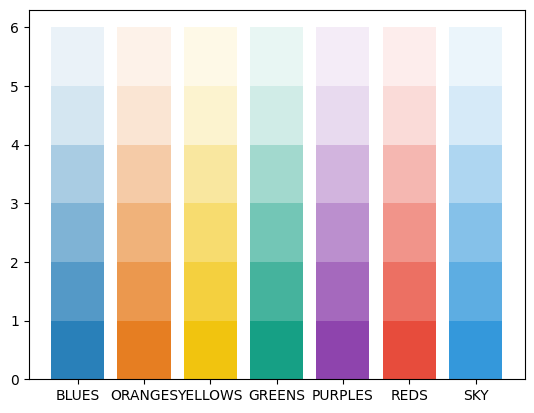

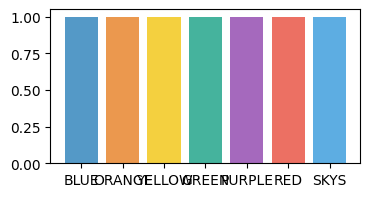

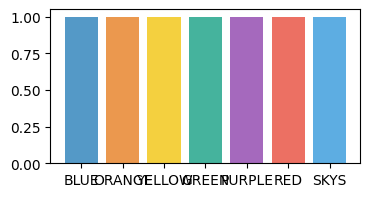

<Figure size 400x200 with 0 Axes>

In [7]:
_, grad_colors = display_colors()
_, bar_colors = select_color_idx(4)
_, line_colors = select_color_idx(4)

In [8]:
plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5

## Experiment 1: limit = 16k

In [9]:
idxs = ["g_total_buf_sz", "read_perc_","zipf_theta_"]
datadir = "../output/"
exp_page = "debug_exp_point_10g_page_fanout250"
exp_tuple = "debug_exp_point_10g_tuple"
exp_remote = "debug_exp_point_10g_remote"
# exp = "exp_point_10g_fanout250"

In [10]:
data_page = [json.loads(line) for line in open(datadir + exp_page + ".txt")]
df_page = pd.DataFrame().from_records(data_page)
data_tuple = [json.loads(line) for line in open(datadir + exp_tuple + ".txt")]
df_tuple = pd.DataFrame().from_records(data_tuple)
data_remote = [json.loads(line) for line in open(datadir + exp_remote + ".txt")]
df_remote = pd.DataFrame().from_records(data_remote)

df = pd.concat([df_page, df_tuple, df_remote])
print(df)
df["id"] = range(df.shape[0])

   g_index_type  g_idx_btree_fanout  g_idx_btree_split_ratio g_buf_type  \
0         BTREE                 250                      0.9      PGBUF   
1         BTREE                 250                      0.9      PGBUF   
2         BTREE                 250                      0.9      PGBUF   
3         BTREE                 250                      0.9      PGBUF   
4         BTREE                 250                      0.9      PGBUF   
5         BTREE                 250                      0.9      PGBUF   
6         BTREE                 250                      0.9      PGBUF   
7         BTREE                 250                      0.9      PGBUF   
8         BTREE                 250                      0.9      PGBUF   
9         BTREE                 250                      0.9      PGBUF   
10        BTREE                 250                      0.9      PGBUF   
11        BTREE                 250                      0.9      PGBUF   
0         BTREE          

In [10]:
df.columns

Index(['g_index_type', 'g_idx_btree_fanout', 'g_idx_btree_split_ratio',
       'g_buf_type', 'g_total_buf_sz', 'g_pagebuf_num_slots', 'g_buf_entry_sz',
       'g_enable_group_commit', 'g_commit_queue_limit', 'g_commit_group_sz',
       'g_log_freq_us', 'g_load_to_remote_only', 'g_restore_from_remote',
       'g_check_loaded', 'g_partition_sz', 'g_load_range',
       'g_num_restore_thds', 'g_num_load_thds', 'g_remote_req_retries',
       'g_num_worker_threads', 'g_commit_pool_sz', 'g_cpu_freq',
       'g_warmup_finished', 'g_enable_logging', 'g_force_write', 'g_node_id',
       'g_save_output', 'g_early_lock_release', 'g_enable_phantom_protection',
       'runtime_', 'warmup_time_', 'num_rows_', 'num_req_per_query_',
       'zipf_theta_', 'read_perc_', 'rw_txn_perc_', 'insert_txn_perc_',
       'loading_startkey', 'loading_endkey', 'num_workers_', 'accesses_',
       'misses_', 'idx_misses_', 'idx_accesses_', 'bufferd_idx_pgs_',
       'remote_rds_', 'remote_wrs_', 'remote_rws_', 'remot

In [11]:
# create pivot table
df1 = apply_mask(df, [
    ["g_buf_type", ["eq", "OBJBUF"]]
])
pivot = df1.groupby(idxs)[[
    "throughput_txn_per_sec","abort_cnt_","hit_rate_","misses_", 
    "avg_log_group_sz_","avg_sum_log_flush_latency (us)",
    "avg_log_latency_ (us)", "avg_log_flush_interval_ (us)", 
    "num_flushes_", "remote_rd_time_ms", "remote_rds_", "commit_cnt_"
]].max()
pivot

throughput_txn_per_sec  abort_cnt_  \
g_total_buf_sz read_perc_ zipf_theta_                                       
1200000000     0.5        0.3                         131.690        1245   
                          0.5                         160.260       13770   
                          0.7                         206.825     1552618   
                          0.9                         134.999    20432549   
               0.9        0.3                         134.620        2136   
                          0.5                         158.650       17332   
                          0.7                         211.810      385651   
                          0.9                         249.940    12843296   
               1.0        0.3                         135.290           0   
                          0.5                         161.040           0   
                          0.7                         217.356           0   
                          0.9                         434.416           0   

                                       hit_rate_  misses_  avg_log_group_sz_  \
g_total_buf_sz read_perc_ zipf_theta_                                          
1200000000     0.5        0.3           0.225890   197014            3.43593   
                          0.5           0.438458   203266            4.30998   
                          0.7           0.971423   190579            6.93547   
                          0.9           0.999302    62738            3.39694   
               0.9        0.3           0.240949   201301            2.60706   
                          0.5           0.401646   201419            3.04782   
                          0.7           0.878240   194931            4.20020   
                          0.9           0.998149   115358            5.55821   
               1.0        0.3           0.222410   202297            2.50950   
                          0.5           0.340281   204195            2.88658   
                          0.7           0.520870   200088            3.96943   
                          0.9           0.761578   198811            8.25903   

                                       avg_sum_log_flush_latency (us)  \
g_total_buf_sz read_perc_ zipf_theta_                                   
1200000000     0.5        0.3                                12492.40   
                          0.5                                13108.60   
                          0.7                                16142.20   
                          0.9                                11219.50   
               0.9        0.3                                 9393.29   
                          0.5                                 9432.01   
                          0.7                                 9846.14   
                          0.9                                10843.60   
               1.0        0.3                                 8972.85   
                          0.5                                 8772.21   
                          0.7                                 9051.22   
                          0.9                                 9463.88   

                                       avg_log_latency_ (us)  \
g_total_buf_sz read_perc_ zipf_theta_                          
1200000000     0.5        0.3                        22355.9   
                          0.5                        22660.9   
                          0.7                        24652.2   
                          0.9                        16980.3   
               0.9        0.3                        14781.6   
                          0.5                        14873.9   
                          0.7                        15415.7   
                          0.9                        14292.6   
               1.0        0.3                        14004.1   
                          0.5                        13713.5   
                          0.7                   

In [12]:
# create pivot table
df2 = apply_mask(df, [
    ["g_buf_type", ["eq", "PGBUF"]]
])
print(idxs)
print(df2)
pivot2 = df2.groupby(idxs)[[
    "throughput_txn_per_sec","abort_cnt_","hit_rate_","misses_", 
    "avg_log_group_sz_","avg_sum_log_flush_latency (us)",
    "avg_log_latency_ (us)", "avg_log_flush_interval_ (us)", 
    "num_flushes_", "remote_rd_time_ms", "remote_rds_", "commit_cnt_"
    ]].max()
pivot2

['g_total_buf_sz', 'read_perc_', 'zipf_theta_']
   g_index_type  g_idx_btree_fanout  g_idx_btree_split_ratio g_buf_type  \
0         BTREE                 250                      0.9      PGBUF   
1         BTREE                 250                      0.9      PGBUF   
2         BTREE                 250                      0.9      PGBUF   
3         BTREE                 250                      0.9      PGBUF   
4         BTREE                 250                      0.9      PGBUF   
5         BTREE                 250                      0.9      PGBUF   
6         BTREE                 250                      0.9      PGBUF   
7         BTREE                 250                      0.9      PGBUF   
8         BTREE                 250                      0.9      PGBUF   
9         BTREE                 250                      0.9      PGBUF   
10        BTREE                 250                      0.9      PGBUF   
11        BTREE                 250                 

throughput_txn_per_sec  abort_cnt_  \
g_total_buf_sz read_perc_ zipf_theta_                                       
1200000000     0.5        0.3                         66.9155           0   
                          0.5                         72.3931        4349   
                          0.7                         87.5377     1223098   
                          0.9                         79.3966     6737742   
               0.9        0.3                         68.4654           0   
                          0.5                         74.5523        5545   
                          0.7                         92.2387      181994   
                          0.9                        133.0280     4712544   
               1.0        0.3                         68.3905           0   
                          0.5                         73.9460           0   
                          0.7                         93.0069           0   
                          0.9                        169.5960           0   

                                       hit_rate_  misses_  avg_log_group_sz_  \
g_total_buf_sz read_perc_ zipf_theta_                                          
1200000000     0.5        0.3           0.762165   151197           34.71120   
                          0.5           0.829360   151048           41.46190   
                          0.7           0.994477   146818           75.52860   
                          0.9           0.999561    71182           73.55810   
               0.9        0.3           0.761020   157417            2.12387   
                          0.5           0.812623   157791            2.30082   
                          0.7           0.971606   156802            3.31986   
                          0.9           0.999063   123942            7.30467   
               1.0        0.3           0.761972   156562            1.89947   
                          0.5           0.779777   156742            2.06766   
                          0.7           0.823026   158312            2.88536   
                          0.9           0.903351   157327           12.40650   

                                       avg_sum_log_flush_latency (us)  \
g_total_buf_sz read_perc_ zipf_theta_                                   
1200000000     0.5        0.3                                255890.0   
                          0.5                                284185.0   
                          0.7                                429503.0   
                          0.9                                459362.0   
               0.9        0.3                                 14670.2   
                          0.5                                 14860.4   
                          0.7                                 17853.3   
                          0.9                                 27326.5   
               1.0        0.3                                 12814.0   
                          0.5                                 13219.3   
                          0.7                                 15291.0   
                          0.9                                 36525.0   

                                       avg_log_latency_ (us)  \
g_total_buf_sz read_perc_ zipf_theta_                          
1200000000     0.5        0.3                       115169.0   
                          0.5                       107493.0   
                          0.7                        91576.1   
                          0.9                        86394.9   
               0.9        0.3                        25111.2   
                          0.5                        25303.1   
                          0.7                        30395.9   
                          0.9                        37156.5   
               1.0        0.3                        20721.9   
                          0.5                        21752.2   
                          0.7                   

In [14]:
# create pivot table
# df0 = pd.DataFrame().from_records([json.loads(line) for line in open(datadir + "different_settings/" + 
#                                                                      "microbench_zipf_10g_fanout18.out")])
df3 = apply_mask(df, [
    ["g_buf_type", ["eq", "NOBUF"]]
])
pivot3 = df3.groupby(idxs)[[
    "throughput_txn_per_sec","abort_cnt_","hit_rate_","misses_", 
    "avg_log_group_sz_","avg_sum_log_flush_latency (us)",
    "avg_log_latency_ (us)", "avg_log_flush_interval_ (us)", 
    "num_flushes_", "g_buf_type", "remote_rds_"
]].max()
pivot3

throughput_txn_per_sec  abort_cnt_  \
g_total_buf_sz read_perc_ zipf_theta_                                       
1200000000     0.5        0.3                        42.91540           0   
                          0.5                        39.71610           8   
                          0.7                        16.08870        1816   
                          0.9                         1.65527        4545   
               0.9        0.3                        93.27830           0   
                          0.5                        94.90280           6   
                          0.7                        48.37650         302   
                          0.9                        10.48550        3524   
               1.0        0.3                        91.82350           0   
                          0.5                        91.73120           0   
                          0.7                        51.21990           0   
                          0.9                        22.10190           0   

                                       hit_rate_  misses_  avg_log_group_sz_  \
g_total_buf_sz read_perc_ zipf_theta_                                          
1200000000     0.5        0.3                0.0   104960            1.23233   
                          0.5                0.0    97023            1.21857   
                          0.7                0.0    54849            1.05723   
                          0.9                0.0    30474            1.00465   
               0.9        0.3                0.0   209936            2.00627   
                          0.5                0.0   212544            1.98278   
                          0.7                0.0   118357            1.21353   
                          0.9                0.0    48925            1.01641   
               1.0        0.3                0.0   207600            1.91313   
                          0.5                0.0   206752            1.87432   
                          0.7                0.0   124400            1.27252   
                          0.9                0.0    55632            1.04310   

                                       avg_sum_log_flush_latency (us)  \
g_total_buf_sz read_perc_ zipf_theta_                                   
1200000000     0.5        0.3                                 7897.04   
                          0.5                                 7877.57   
                          0.7                                 7519.68   
                          0.9                                 7757.13   
               0.9        0.3                                 9901.27   
                          0.5                                 9650.56   
                          0.7                                 7181.70   
                          0.9                                 7312.60   
               1.0        0.3                                 9418.15   
                          0.5                                 9079.88   
                          0.7                                 7559.99   
                          0.9                                 7204.24   

                                       avg_log_latency_ (us)  \
g_total_buf_sz read_perc_ zipf_theta_                          
1200000000     0.5        0.3                       10894.40   
                          0.5                       10833.70   
                          0.7                        8927.37   
                          0.9                        7961.96   
               0.9        0.3                       15362.20   
                          0.5                       14917.60   
                          0.7                        9901.82   
                          0.9                        8058.06   
               1.0        0.3                       14466.10   
                          0.5                       13939.60   
                          0.7                   

In [20]:
pivot.index.levels[1]

Index([0.5], dtype='float64', name='read_perc_')

In [19]:
pivot.index.levels[0]

Index([1200000000], dtype='int64', name='g_total_buf_sz')

In [16]:
pivot.index.levels[workload_col]

Index([1200000000], dtype='int64', name='g_total_buf_sz')

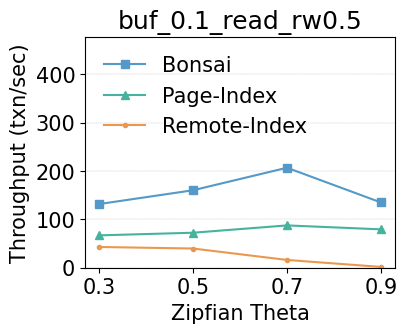

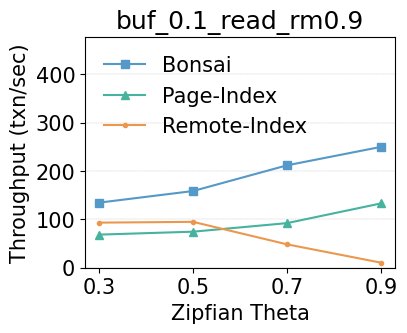

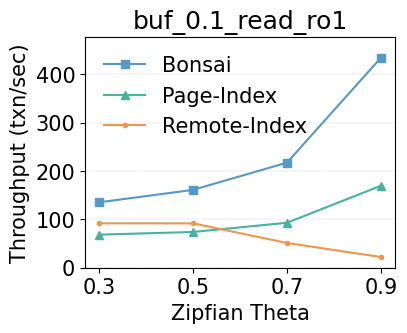

In [16]:
import matplotlib.ticker as mtick
def y_axis_formatter(x, pos):
    # Check if the value is in the thousands
    if x >= 1000:
        # Format as "1k" and divide by 1000
        return f"{int(x/1000)}k"
    else:
        return "%.1fk"%(x / 1000.0)
workload_col = 0
zipf_col = 2
read_col = 1
# pivot = pivot2
workload_ratio = [sz / 10240000000.0 for sz in pivot.index.levels[workload_col]]
workload_names = ["s", "m", "l", "xl"]
read_names = ["rw", "rm", "ro"]
buf_ratio = ["0.1"]
read_ratio = ["0.5", "0.9", "1"]
zipf_names = ["zf%.f"%(z * 10) for z in pivot.index.levels[zipf_col]]
# path = "~/Desktop/Bonsai/figures/point_by_size/"
zipf_names
for i, x in enumerate(pivot.index.levels[workload_col]):
    plot_data = pivot.loc[x]
    plot_data2 = pivot2.loc[x]
    # plot_data3 = pivot3.loc[0]
    plot_data3 = pivot3.loc[x]
    max_throughput = max(plot_data["throughput_txn_per_sec"].max(), plot_data2["throughput_txn_per_sec"].max()) * 1.1 
    for j, y in enumerate(pivot.index.levels[read_col]):
        fig, ax = plt.subplots()
        # xval = range(len(pivot.index.levels[read_col]))
        xval = pivot.index.levels[zipf_col]
        ax.plot(xval, 
                plot_data.loc[y]["throughput_txn_per_sec"],
                color=line_colors["BLUE"],
                marker="s", label="Bonsai")
        ax.plot(xval, 
                plot_data2.loc[y]["throughput_txn_per_sec"],
                color=line_colors["GREEN"],
                marker="^", label="Page-Index")
        ax.plot(xval, 
                plot_data3.loc[y]["throughput_txn_per_sec"],
                color=line_colors["ORANGE"],
                marker=".", label="Remote-Index")
        ax.set_ylim(0, max_throughput)
        #ax.set_xlim(0, 1)
        ax.set_xticks(xval)
        location = "upper left"
        if i == 3:
            location = "lower left"
        ax.legend(loc=location, frameon=False)
        ax.set_ylabel("Throughput (txn/sec)")
        ax.set_xlabel("Zipfian Theta")
        ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
        #ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
        ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
        fig.set_size_inches(4, 3)
        # fig.savefig(path + "point_10g_fanout250_limit16k_{}_{}.pdf".format(
        #     workload_names[i], read_names[j]), bbox_inches="tight")    

In [ ]:
#(pivot2["remote_rds_"] / pivot2["commit_cnt_"]) / (pivot["remote_rds_"] / pivot["commit_cnt_"])

In [118]:
pivot.loc[3000000000].loc[1.0].loc[0.3]["remote_rd_time_ms"] / pivot.loc[3000000000].loc[1.0].loc[0.3]["remote_rds_"] 

3.7501154354852595

In [119]:
pivot2.loc[3000000000].loc[1.0].loc[0.3]["remote_rd_time_ms"] / pivot2.loc[3000000000].loc[1.0].loc[0.3]["remote_rds_"] 

5.3403957870347165

In [120]:
5.3403957870347165 / 3.7501154354852595

1.4240617066081533

In [17]:
pivot.loc[3000000000]["throughput_txn_per_sec"] / pivot3.loc[0]["throughput_txn_per_sec"]

read_perc_  zipf_theta_
0.5         0.3             2.114719
            0.5             2.684129
            0.7             3.898335
            0.9            11.594920
0.9         0.3             1.679341
            0.5             2.073619
            0.7             3.079240
            0.9             6.926736
1.0         0.3             1.654505
            0.5             2.091379
            0.7             3.035866
            0.9             6.420212
Name: throughput_txn_per_sec, dtype: float64

In [24]:
pivot.loc[3000000000]["throughput_txn_per_sec"] / pivot2.loc[3000000000]["throughput_txn_per_sec"]

read_perc_  zipf_theta_
0.5         0.3            2.382787
            0.5            2.657553
            0.7            2.847673
            0.9            3.272275
0.9         0.3            2.377156
            0.5            2.652108
            0.7            2.900833
            0.9            2.796381
1.0         0.3            2.326457
            0.5            2.581222
            0.7            2.901825
            0.9            3.152853
Name: throughput_txn_per_sec, dtype: float64

In [25]:
pivot.loc[6000000000]["throughput_txn_per_sec"] / pivot2.loc[6000000000]["throughput_txn_per_sec"]

read_perc_  zipf_theta_
0.5         0.3            2.736000
            0.5            2.440459
            0.7            1.972811
            0.9            3.170106
0.9         0.3            2.787895
            0.5            3.156531
            0.7            3.618440
            0.9            3.624589
1.0         0.3            2.767093
            0.5            3.179769
            0.7            3.572924
            0.9            3.884809
Name: throughput_txn_per_sec, dtype: float64

In [26]:
pivot.loc[15000000000]["throughput_txn_per_sec"] / pivot2.loc[15000000000]["throughput_txn_per_sec"]

read_perc_  zipf_theta_
0.5         0.3            0.909564
            0.5            0.989804
            0.7            0.951627
            0.9            0.921598
0.9         0.3            0.954494
            0.5            1.032134
            0.7            1.029875
            0.9            1.085413
1.0         0.3            0.998238
            0.5            0.935820
            0.7            1.010814
            0.9            1.050450
Name: throughput_txn_per_sec, dtype: float64

In [28]:
(pivot.loc[6000000000]["throughput_txn_per_sec"] / pivot2.loc[6000000000]["throughput_txn_per_sec"]).min()

1.9728107885010457

In [29]:
(pivot.loc[6000000000]["throughput_txn_per_sec"] / pivot2.loc[6000000000]["throughput_txn_per_sec"]).max()

3.884809326964636